<a href="https://colab.research.google.com/github/MexicoHamburger/AIP-2/blob/main/CarrerPrediction_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TabTransformer Multi‑Task Workflow
엔드‑투‑엔드 예시 노트북 (10 % 샘플·train/val/test 분할 포함)

> Stack Overflow Dev Survey 2024 전처리 결과 CSV를 업로드한 뒤, **`DATA_CSV` 변수 경로만 수정**하고 셀을 순서대로 실행하세요.

In [1]:
!pip install pandas scikit-learn torch tabtransformer-pytorch matplotlib --quiet

ERROR: Could not find a version that satisfies the requirement tabtransformer-pytorch (from versions: none)
ERROR: No matching distribution found for tabtransformer-pytorch


## 1. 데이터 로드 & 10 % 샘플링

In [3]:
import pandas as pd, numpy as np, os, random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from google.colab import files
import io

# --- 파일 업로드 ---
uploaded = files.upload()
filename = next(iter(uploaded))
DATA_CSV = filename

# --- 다중-라벨 컬럼 정의 ---
multi_cols = [
    "LanguageHaveWorkedWith", "LanguageWantToWorkWith",
    "DatabaseHaveWorkedWith", "DatabaseWantToWorkWith",
    "PlatformHaveWorkedWith", "PlatformWantToWorkWith",
    "WebframeHaveWorkedWith", "WebframeWantToWorkWith",
    "EmbeddedHaveWorkedWith", "EmbeddedWantToWorkWith",
    "MiscTechHaveWorkedWith", "MiscTechWantToWorkWith",
    "ToolsTechHaveWorkedWith", "ToolsTechWantToWorkWith",
    "ProfessionalTech",
]

def split_pipe(x):
    """예: 'A;B;C' → ['A','B','C']"""
    return [] if pd.isna(x) else [i.strip() for i in x.split(";")]

# --- 파일 읽기 ---
raw = pd.read_csv(io.BytesIO(uploaded[DATA_CSV]))

# 문자열 → 리스트 변환
for c in multi_cols:
    if c in raw.columns:
        raw[c] = raw[c].apply(split_pipe)

# 핵심 숫자 결측 제거
raw = raw.dropna(subset=["CompTotal", "JobSat"])

# 10 % 샘플링
# raw = raw.sample(frac=0.10, random_state=42).reset_index(drop=True)

print("샘플 수:", len(raw))
raw.head(3)


Saving SODC_2024.csv to SODC_2024.csv
샘플 수: 12275


,DevType,CompTotal,LanguageHaveWorkedWith,LanguageWantToWorkWith,DatabaseHaveWorkedWith,DatabaseWantToWorkWith,PlatformHaveWorkedWith,PlatformWantToWorkWith,WebframeHaveWorkedWith,WebframeWantToWorkWith,EmbeddedHaveWorkedWith,EmbeddedWantToWorkWith,MiscTechHaveWorkedWith,MiscTechWantToWorkWith,ToolsTechHaveWorkedWith,ToolsTechWantToWorkWith,ProfessionalTech,ProfessionalQuestion,Industry,JobSat
1,Data scientist or machine learning specialist,127500000.0,"[JavaScript, Python, SQL, TypeScript]","[Go, JavaScript, Python, Rust, SQL, TypeScript]","[PostgreSQL, SQLite]","[PostgreSQL, SQLite]","[Amazon Web Services (AWS), Cloudflare, Digita...","[Amazon Web Services (AWS), Cloudflare, Google...","[Next.js, React, Vue.js]","[Svelte, Vue.js]",[],[],"[NumPy, Pandas, Scikit-Learn, Torch/PyTorch]","[NumPy, Pandas, Scikit-Learn, Torch/PyTorch]","[Ansible, Make, Vite]",[Vite],[Developer portal or other central places to f...,AI-powered search (paid),Computer Systems Design and Services,10.0
2,Engineering manager,214914000.0,"[C#, HTML/CSS, Java, JavaScript, Python, TypeS...","[HTML/CSS, JavaScript, Python, TypeScript]","[Oracle, PostgreSQL]","[PostgreSQL, Redis]",[Amazon Web Services (AWS)],[Amazon Web Services (AWS)],[React],[React],[],[],[],[],"[Gradle, Maven (build tool)]","[Gradle, Maven (build tool)]",[],Traditional public search engine,Retail and Consumer Services,7.0
3,"Developer, full-stack",267150000.0,"[Bash/Shell (all shells), C#, HTML/CSS, JavaSc...","[C#, HTML/CSS, JavaScript, SQL, TypeScript]","[Microsoft SQL Server, PostgreSQL]","[Microsoft SQL Server, MongoDB, PostgreSQL]",[Microsoft Azure],"[Amazon Web Services (AWS), Google Cloud, Micr...","[Angular, ASP.NET CORE, React]","[Angular, ASP.NET CORE, Htmx, jQuery, React]",[],[],"[.NET (5+), RabbitMQ, React Native]","[.NET (5+), Flutter, RabbitMQ, React Native]","[Chocolatey, Docker, Visual Studio Solution, Y...","[Docker, Visual Studio Solution]","[DevOps function, Automated testing, Observabi...",Traditional public search engine,Healthcare,5.0


## 2. Multi‑Label Binarizer → 입·출력 행렬

In [17]:
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler

# ---- 입력 X ----
mlb = {c: MultiLabelBinarizer().fit(raw[c]) for c in multi_cols}
X_parts = [mlb[c].transform(raw[c]) for c in multi_cols]
X = np.hstack(X_parts).astype("float32")

# ---- 멀티-라벨 타깃 ----
y_role = raw["DevType"].str.get_dummies(";").astype("float32").values   # (N, n_role)
y_ind  = raw["Industry"].str.get_dummies(";").astype("float32").values  # (N, n_ind)
n_role = y_role.shape[1]

# ---- 연봉: 표준화 후 직무별 행렬 ----
# 1. 원본 연봉 가져오기
comp = raw["CompTotal"].values.astype("float64")  # float64로 우선 변환

# 2. 비정상적으로 큰 값 제거 (예: 상위 1% 컷오프)
q99 = np.nanpercentile(comp, 99)
valid_mask = (comp < q99) & (~np.isnan(comp))  # NaN 아닌 값 중 상위 1% 초과 제거

# 3. StandardScaler 학습
scaler = StandardScaler()
scaled_valid = scaler.fit_transform(comp[valid_mask].reshape(-1, 1)).flatten()

# 4. 전체 스케일링된 벡터 생성
y_sal_scalar = np.full_like(comp, np.nan, dtype="float32")
y_sal_scalar[valid_mask] = scaled_valid.astype("float32")  # float32 변환

# 5. 직무별 연봉 매트릭스
n_role = y_role.shape[1]
y_sal_mat = np.tile(y_sal_scalar[:, None], (1, n_role))
y_sal_role = np.where(y_role == 1, y_sal_mat, np.nan).astype("float32")

# ---- 만족도: 직무별 행렬 ----
y_sat_scalar = raw["JobSat"].astype("float32").values
y_sat_mat = np.tile(y_sat_scalar[:, None], (1, n_role))
y_sat_role = np.where(y_role == 1, y_sat_mat, np.nan).astype("float32") # ★


## 3. train / val / test 3‑way split

In [18]:
TEST_RATIO = 0.20
VAL_RATIO  = 0.16

X_tmp, X_test, yR_tmp, yR_test, yI_tmp, yI_test, yS_tmp, yS_test, yT_tmp, yT_test = train_test_split(
    X, y_role, y_ind, y_sal_role, y_sat_role, test_size=TEST_RATIO, random_state=42)

val_ratio_adj = VAL_RATIO / (1 - TEST_RATIO)
X_train, X_val, yR_train, yR_val, yI_train, yI_val, yS_train, yS_val, yT_train, yT_val = train_test_split(
    X_tmp, yR_tmp, yI_tmp, yS_tmp, yT_tmp, test_size=val_ratio_adj, random_state=42)

for name, arr in [("train", X_train), ("val", X_val), ("test", X_test)]:
    print(f"{name:<5}  {arr.shape[0]:>6} samples")


train    7856 samples
val      1964 samples
test     2455 samples


## 4. TabTransformer 모델 정의

In [19]:
import torch, torch.nn as nn, torch.nn.functional as F

class TabTransformer(nn.Module):
    def __init__(self, input_dim, embed_dim=64, depth=4, heads=8, dropout=0.3):
        super().__init__()
        self.embedding = nn.Linear(input_dim, embed_dim)
        enc_layer = nn.TransformerEncoderLayer(embed_dim, heads, embed_dim*4,
                                               dropout=dropout, activation='gelu',
                                               batch_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=depth)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.embedding(x).unsqueeze(1)
        x = self.encoder(x)
        return self.dropout(x.mean(1))

class MultiTaskTab(nn.Module):
    def __init__(self, in_dim, n_role, n_ind):
        super().__init__()
        self.backbone = TabTransformer(in_dim)
        self.role_head = nn.Sequential(nn.Linear(64, n_role), nn.Sigmoid())
        self.ind_head  = nn.Sequential(nn.Linear(64, n_ind),  nn.Sigmoid())

        # ---- 직무별 회귀 벡터 ---- ★
        self.sal_head  = nn.Linear(64, n_role)   # 연봉
        self.sat_head  = nn.Linear(64, n_role)   # 만족도

    def forward(self, x):
        feat = self.backbone(x)
        return (
            self.role_head(feat),            # r_prob  (B, n_role)
            self.ind_head(feat),             # i_prob  (B, n_ind)
            self.sal_head(feat),             # s_hat   (B, n_role)
            self.sat_head(feat),             # t_hat   (B, n_role)
        )


## 5. DataLoader & 하이퍼파라미터 설정

In [20]:
%env CUDA_LAUNCH_BLOCKING=1


env: CUDA_LAUNCH_BLOCKING=1


In [21]:
from torch.utils.data import TensorDataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"

def make_loader(X, yR, yI, yS, yT, bs, shuffle):
    # NaN → 0.0 처리 (텐서 생성 전)
    yS = np.nan_to_num(yS, nan=0.0)
    yT = np.nan_to_num(yT, nan=0.0)

    ds = TensorDataset(torch.tensor(X, dtype=torch.float32),
                       torch.tensor(yR, dtype=torch.float32),
                       torch.tensor(yI, dtype=torch.float32),
                       torch.tensor(yS, dtype=torch.float32),
                       torch.tensor(yT, dtype=torch.float32))
    return DataLoader(ds, batch_size=bs, shuffle=shuffle)


tr_loader  = make_loader(X_train, yR_train, yI_train, yS_train, yT_train, bs=256, shuffle=True)
val_loader = make_loader(X_val,   yR_val,   yI_val,   yS_val,   yT_val,   bs=512, shuffle=False)
test_loader= make_loader(X_test,  yR_test,  yI_test,  yS_test,  yT_test,  bs=512, shuffle=False)
print("y_ind.shape:", y_ind.shape)
print("X.shape:", X.shape)
model = MultiTaskTab(X.shape[1], n_role, y_ind.shape[1]).to(device)
opt   = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)

def loss_fn(outputs, yR, yI, yS, yT):
    r, i, s, t = outputs          # shapes: (B,n_role) …
    loss_role = F.binary_cross_entropy(r, yR)
    loss_ind  = F.binary_cross_entropy(i, yI)

    # ---- 직무 존재 마스크 ----
    mask = (yR > 0.5)             # Bool, 같은 shape
    s_loss = F.mse_loss(s[mask], yS[mask])
    t_loss = F.mse_loss(t[mask], yT[mask])

    return loss_role + loss_ind + 0.001 * s_loss + 0.1 * t_loss



y_ind.shape: (12275, 14)
X.shape: (12275, 195)


## 6. 학습 루프 (early stopping, 과적합 관찰)

In [22]:
EPOCHS = 1000             # 최대 epoch 수
PATIENCE = 10            # 검증 손실 향상 없을 경우 허용 횟수
BEST_VAL = float('inf')  # 현재까지 최소 검증 손실
WAIT = 0                 # 향상 없이 기다린 epoch 수
BEST_STATE = None        # 모델 가중치 저장용

history = {"train": [], "val": []}

for ep in range(1, EPOCHS+1):
    # --- Training ---
    model.train()
    total_loss, n_total = 0.0, 0

    for xb, yR, yI, yS, yT in tr_loader:
        xb, yR, yI, yS, yT = xb.to(device), yR.to(device), yI.to(device), yS.to(device), yT.to(device)
        opt.zero_grad()
        loss = loss_fn(model(xb), yR, yI, yS, yT)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        opt.step()
        total_loss += loss.item() * len(xb)
        n_total += len(xb)

    train_loss = total_loss / n_total
    history["train"].append(train_loss)

    # --- Validation ---
    model.eval()
    val_loss, n_val = 0.0, 0
    with torch.no_grad():
        for xb, yR, yI, yS, yT in val_loader:
            xb, yR, yI, yS, yT = xb.to(device), yR.to(device), yI.to(device), yS.to(device), yT.to(device)
            batch_loss = loss_fn(model(xb), yR, yI, yS, yT)
            if not torch.isnan(batch_loss) and not torch.isinf(batch_loss):
                val_loss += batch_loss.item() * len(xb)
                n_val += len(xb)

    val_avg = val_loss / n_val if n_val > 0 else float('inf')
    history["val"].append(val_avg)

    # --- 로그 출력 ---
    print(f"Epoch {ep:3d} | train={train_loss:.4f} | val={val_avg:.4f}")

    # --- Early Stopping 체크 ---
    if val_avg < BEST_VAL:
        BEST_VAL = val_avg
        WAIT = 0
        BEST_STATE = model.state_dict()  # 가중치 저장
        BEST_EPOCH = ep
    else:
        WAIT += 1
        if WAIT >= PATIENCE:
            print(f"🛑 Early stopping at epoch {ep} (best epoch: {BEST_EPOCH})")
            break

# --- 학습 후 best 모델 복원 ---
model.load_state_dict(BEST_STATE)


Epoch   1 | train=5.6184 | val=4.4265
Epoch   2 | train=4.3485 | val=3.7203
Epoch   3 | train=3.8486 | val=3.3542
Epoch   4 | train=3.5189 | val=3.0596
Epoch   5 | train=3.2184 | val=2.7889
Epoch   6 | train=2.9363 | val=2.5332
Epoch   7 | train=2.6929 | val=2.2938
Epoch   8 | train=2.4422 | val=2.0746
Epoch   9 | train=2.2262 | val=1.8803
Epoch  10 | train=2.0253 | val=1.7074
Epoch  11 | train=1.8494 | val=1.5540
Epoch  12 | train=1.6827 | val=1.4190
Epoch  13 | train=1.5411 | val=1.3015
Epoch  14 | train=1.4177 | val=1.2009
Epoch  15 | train=1.3110 | val=1.1142
Epoch  16 | train=1.2130 | val=1.0447
Epoch  17 | train=1.1430 | val=0.9934
Epoch  18 | train=1.0807 | val=0.9545
Epoch  19 | train=1.0347 | val=0.9250
Epoch  20 | train=1.0045 | val=0.8996
Epoch  21 | train=0.9759 | val=0.8806
Epoch  22 | train=0.9481 | val=0.8673
Epoch  23 | train=0.9322 | val=0.8551
Epoch  24 | train=0.9204 | val=0.8468
Epoch  25 | train=0.9113 | val=0.8380
Epoch  26 | train=0.8955 | val=0.8312
Epoch  27 | 

<All keys matched successfully>

## 7. Train vs Val Loss 곡선

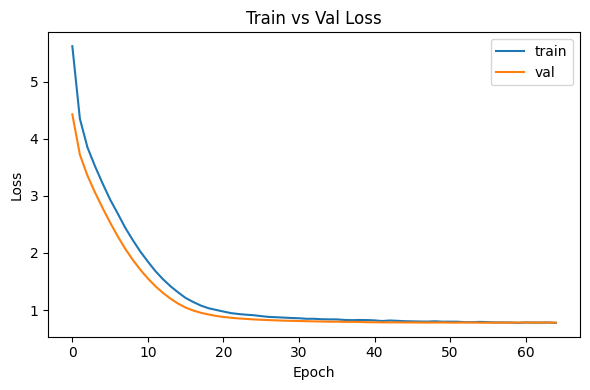

In [23]:

import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(history["train"], label="train")
plt.plot(history["val"],   label="val")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.title("Train vs Val Loss")
plt.tight_layout(); plt.show()


## 8. Test 세트 최종 평가

In [24]:
model.eval()
test_loss, n = 0.0, 0

with torch.no_grad():
    for xb, yR, yI, yS, yT in test_loader:
        xb, yR, yI, yS, yT = xb.to(device), yR.to(device), yI.to(device), yS.to(device), yT.to(device)
        tl = loss_fn(model(xb), yR, yI, yS, yT)

        # ✅ NaN 또는 inf 값은 제외
        if not torch.isnan(tl) and not torch.isinf(tl):
            test_loss += tl.item() * len(xb)
            n += len(xb)

# ✅ n이 0일 경우 예외 처리
test_avg = test_loss / n if n > 0 else float('inf')
print(f"Test loss: {test_avg:.4f}")


Test loss: 0.7745


# =========================================
# 🔍 9. Dummy 입력 → 모델 예측 & 읽기-쉬운 출력
# =========================================

In [26]:
from sklearn.metrics.pairwise import cosine_similarity

dummy_input = {
    "LanguageHaveWorkedWith": ["C"],
    "DatabaseHaveWorkedWith": [],
    "PlatformHaveWorkedWith": [],
    "WebframeHaveWorkedWith": ["FastAPI"],
    "EmbeddedHaveWorkedWith": ["GNU GCC"],
    "MiscTechHaveWorkedWith": ["Torch/PyTorch"],
    "ToolsTechHaveWorkedWith": [],
    "ProfessionalTech": [],
}

# ---- 멀티-핫 인코딩 ----
x_dummy = np.hstack([mlb[c].transform([dummy_input.get(c, [])])
                     for c in multi_cols]).astype("float32")

# ---- 모델 추론 ----
model.eval()
with torch.no_grad():
    r_prob, i_prob, s_hat, t_hat = model(torch.tensor(x_dummy).to(device))
r_prob, i_prob = r_prob.cpu().numpy()[0], i_prob.cpu().numpy()[0]
s_hat, t_hat   = s_hat.cpu().numpy()[0], t_hat.cpu().numpy()[0]

# ---- 상위 3개 직무 & 산업 ----
role_cols = raw["DevType"].str.get_dummies(";").columns
ind_cols  = raw["Industry"].str.get_dummies(";").columns
top_role_idx = r_prob.argsort()[-3:][::-1]
top_roles    = role_cols[top_role_idx]
top_inds     = ind_cols[np.argsort(-i_prob)[:3]]

# ---- 연봉·만족도 역변환 ----
print("s_hat:", s_hat[top_role_idx])
print("scale_:", scaler.scale_)
print("mean_ :", scaler.mean_)

sal_preds = scaler.inverse_transform(s_hat[top_role_idx].reshape(-1,1)).flatten()
sat_preds = t_hat[top_role_idx]

# ---- 최근접 이웃 & 유사도 가중 스택 추천 ----
K_NEI = 50
sims = cosine_similarity(x_dummy, X)[0]
nbrs = raw.iloc[sims.argsort()[-K_NEI:][::-1]].copy()
nbrs["sim"] = sims[sims.argsort()[-K_NEI:][::-1]]

def weighted_median(values, weights):
    order = np.argsort(values); v,w = values[order], weights[order]
    c = np.cumsum(w); return v[c >= 0.5*w.sum()][0]

have = set(sum(dummy_input.values(), []))
role_stats = []

for idx, role in zip(top_role_idx, top_roles):
    sub = nbrs[nbrs["DevType"].str.contains(role, regex=False)]

    # 추천 스택
    nei_items = sum(sub[multi_cols].values.flatten().tolist(), [])
    candidate = (pd.Series(nei_items).value_counts()
             .loc[lambda s: ~s.index.isin(have)].head(3).index.tolist())


    # 편차 기반 보완 연봉 계산 (방법 A)
    with_stack = sub[multi_cols].apply(
        lambda row: any(s in sum(row.values.tolist(), []) for s in candidate), axis=1)
    sub_with = sub[with_stack]
    sub_without = sub[~with_stack]

    if len(sub_with) >= 1 and len(sub_without) >= 1:
        med_with = weighted_median(sub_with["CompTotal"].values, sub_with["sim"].values)
        med_wo   = weighted_median(sub_without["CompTotal"].values, sub_without["sim"].values)
        delta = np.clip(med_with - med_wo, 0, 20000)
        boost_pay = sal_preds[list(top_roles).index(role)] + delta
    else:
        boost_pay = np.nan

    role_stats.append({
        "직무(모델)": role,
        "예상 연봉(모델)": f"{sal_preds[list(top_roles).index(role)]:,.0f}원",
        "예상 만족도(모델)": f"{sat_preds[list(top_roles).index(role)]:.2f}/10",
        "추천 보완 스택": ", ".join(candidate),
        "보완 시 연봉 (가중 중앙값 + 클리핑)": f"{boost_pay:,.0f}원" if not np.isnan(boost_pay) else "N/A",
    })

# ---- 결과 출력 ----
print("모델 예측 산업군:", ", ".join(top_inds))
pd.DataFrame(role_stats)


s_hat: [0.08180442 0.23035151 0.01173316]
scale_: [88050448.00210834]
mean_ : [1.25661397e+08]
모델 예측 산업군: Software Development, Internet, Telecomm or Information Services, Fintech


,직무(모델),예상 연봉(모델),예상 만족도(모델),추천 보완 스택,보완 시 연봉 (가중 중앙값 + 클리핑)
0,"Developer, back-end","132,864,312원",6.95/10,"Python, Pip, Make","132,884,312원"
1,"Developer, full-stack","145,943,952원",7.36/10,"C++, CMake, SQLite",N/A
2,"Developer, embedded applications or devices","126,694,504원",7.01/10,"C++, CMake, Python","126,694,504원"


# 10. Baseline과 비교

10-1. Top-K 최근접 (KNN baseline)

In [33]:
# ──────────── Top-K 최근접 baseline ────────────
from sklearn.neighbors import NearestNeighbors
import numpy as np

K_NEI   = 50     # 최근접 이웃 개수
TOP_K   = 3      # 직군 / 산업 평가 상위 K
device   # 앞에서 정의돼 있음

# ▒ 학습세트로 KNN 피팅 (cosine)
knn = NearestNeighbors(n_neighbors=K_NEI,
                       metric="cosine",
                       n_jobs=-1).fit(X_train)

# ▒ 훈련셋에서 "대표 연봉·만족도 1개" 추출용 벡터 (각 사람의 최대 직무값)
yS_scalar_train = np.nanmax(np.where(np.isnan(yS_train), -np.inf, yS_train), axis=1)
yS_scalar_train[np.isinf(yS_scalar_train)] = 0  # or np.nan

yT_scalar_train = np.nanmax(np.where(np.isnan(yT_train), -np.inf, yT_train), axis=1)
yT_scalar_train[np.isinf(yT_scalar_train)] = 0

def knn_predict(Xq):
    dists, idx = knn.kneighbors(Xq, return_distance=True)
    sims  = 1 - dists

    R_pred = yR_train[idx].mean(1)
    I_pred = yI_train[idx].mean(1)

    sims_sum = sims.sum(1)
    sims_sum[sims_sum == 0] = 1e-8

    S_pred = (yS_scalar_train[idx] * sims).sum(1) / sims_sum
    T_pred = (yT_scalar_train[idx] * sims).sum(1) / sims_sum
    return R_pred, I_pred, S_pred, T_pred

R_knn, I_knn, S_knn, T_knn = knn_predict(X_test)


10-2. CatBoost baseline (멀티-레이블/레이블별 회귀)

In [34]:
# ──────────── CatBoost baseline ────────────
!pip install -q catboost
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.multioutput import MultiOutputClassifier, MultiOutputRegressor
import numpy as np

# ▒ NaN → 0 (CatBoost 회귀 타깃에서 NaN 허용 안 함)
yS_train_fill = np.nan_to_num(yS_train, nan=0.0)
yT_train_fill = np.nan_to_num(yT_train, nan=0.0)

# ▒ 다중-라벨 분류
clf_role = MultiOutputClassifier(
    CatBoostClassifier(iterations=300, depth=6, learning_rate=0.1,
                       verbose=False, loss_function='Logloss'))
clf_ind  = MultiOutputClassifier(
    CatBoostClassifier(iterations=300, depth=6, learning_rate=0.1,
                       verbose=False, loss_function='Logloss'))

# ▒ 다중 회귀 (직무별)
reg_sal = MultiOutputRegressor(
    CatBoostRegressor(iterations=300, depth=6, learning_rate=0.1,
                      verbose=False, loss_function='MAE'))
reg_sat = MultiOutputRegressor(
    CatBoostRegressor(iterations=300, depth=6, learning_rate=0.1,
                      verbose=False, loss_function='RMSE'))

# 학습
clf_role.fit(X_train, yR_train)
clf_ind .fit(X_train, yI_train)
reg_sal .fit(X_train, yS_train_fill)
reg_sat .fit(X_train, yT_train_fill)

# 예측
R_cat = np.stack([p[:,1] for p in clf_role.predict_proba(X_test)], axis=1)
I_cat = np.stack([p[:,1] for p in clf_ind .predict_proba(X_test)], axis=1)

S_cat_full = reg_sal.predict(X_test)     # (N, n_role)
T_cat_full = reg_sat.predict(X_test)

max_role_idx = R_cat.argmax(1)
S_cat = S_cat_full[np.arange(len(X_test)), max_role_idx]
T_cat = T_cat_full[np.arange(len(X_test)), max_role_idx]


10—3. 공통 평가 함수 & 비교 표

In [36]:
# ──────────── 공통 메트릭 & 세 모델 비교 ────────────
from sklearn.metrics import recall_score, mean_absolute_error, mean_squared_error
import pandas as pd, numpy as np
import torch

def recall_at_k(y_true, y_prob, k):
    topk = np.argsort(-y_prob, axis=1)[:, :k]
    return np.mean([y_true[i, idx].max() for i, idx in enumerate(topk)])

def evaluate(name, R_pred, I_pred, S_pred, T_pred):
    # multi-label recall
    r1 = recall_at_k(yR_test, R_pred, 1)
    r3 = recall_at_k(yR_test, R_pred, 3)
    i1 = recall_at_k(yI_test, I_pred, 1)
    i3 = recall_at_k(yI_test, I_pred, 3)

    # 연봉: NaN 제거 후 평가
    true_sal_raw = np.nanmax(yS_test, axis=1)
    valid_idx = ~np.isnan(true_sal_raw)
    true_sal = scaler.inverse_transform(true_sal_raw[valid_idx].reshape(-1, 1)).flatten()
    pred_sal = scaler.inverse_transform(S_pred[valid_idx].reshape(-1, 1)).flatten()
    sal_mae  = mean_absolute_error(true_sal, pred_sal)

    # 만족도: NaN 제거 후 평가
    true_sat_raw = np.nanmax(yT_test, axis=1)
    valid_idx_sat = ~np.isnan(true_sat_raw)
    rmse_sat = np.sqrt(mean_squared_error(true_sat_raw[valid_idx_sat], T_pred[valid_idx_sat]))

    return pd.Series({
        "Recall@1_role": r1, "Recall@3_role": r3,
        "Recall@1_ind": i1,  "Recall@3_ind": i3,
        "Salary_MAE": sal_mae, "Satisfaction_RMSE": rmse_sat
    }, name=name)


# ─ TabTransformer 예측 (스칼라 = 최대 확률 직무)
model.eval()
with torch.no_grad():
    R_dl, I_dl, S_dl_full, T_dl_full = model(torch.tensor(X_test).to(device))
R_dl, I_dl = R_dl.cpu().numpy(), I_dl.cpu().numpy()
max_idx_dl = R_dl.argmax(1)
S_dl = S_dl_full.cpu().numpy()[np.arange(len(X_test)), max_idx_dl]
T_dl = T_dl_full.cpu().numpy()[np.arange(len(X_test)), max_idx_dl]

# ─ 결과 비교
results = pd.concat([
    evaluate("TabTransformer", R_dl,  I_dl,  S_dl,  T_dl),
    evaluate("TopK",          R_knn, I_knn, S_knn, T_knn),
    evaluate("CatBoost",      R_cat, I_cat, S_cat, T_cat)
], axis=1).T

results.round(4)


<ipython-input-36-1be7bc66596d>:18: RuntimeWarning: All-NaN slice encountered
  true_sal_raw = np.nanmax(yS_test, axis=1)
<ipython-input-36-1be7bc66596d>:18: RuntimeWarning: All-NaN slice encountered
  true_sal_raw = np.nanmax(yS_test, axis=1)
<ipython-input-36-1be7bc66596d>:18: RuntimeWarning: All-NaN slice encountered
  true_sal_raw = np.nanmax(yS_test, axis=1)


,Recall@1_role,Recall@3_role,Recall@1_ind,Recall@3_ind,Salary_MAE,Satisfaction_RMSE
TabTransformer,0.5523,0.8383,0.3927,0.5112,6.700565e+07,2.1254
TopK,0.5959,0.8672,0.3927,0.5271,6.459563e+07,2.1140
CatBoost,0.6155,0.8745,0.3878,0.5385,6.695943e+07,3.7683


from matplotlib import pyplot as plt
_df_0['Recall@1_role'].plot(kind='hist', bins=20, title='Recall@1_role')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['Recall@3_role'].plot(kind='hist', bins=20, title='Recall@3_role')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['Recall@1_ind'].plot(kind='hist', bins=20, title='Recall@1_ind')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_18['index'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_18, x='Recall@3_role', y='index', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_19['index'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_19, x='Recall@1_ind', y='index', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_20['index'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_20, x='Recall@3_ind', y='index', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)